### Briging Data

In [ ]:
import kagglehub
import os
import glob
path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")

Using Colab cache for faster access to the 'lgg-mri-segmentation' dataset.


In [ ]:
print(path)

/kaggle/input/lgg-mri-segmentation


In [ ]:

print(path)
os.listdir(path)

/kaggle/input/lgg-mri-segmentation


['kaggle_3m', 'lgg-mri-segmentation']

In [ ]:
data_dir = os.path.join(path, "kaggle_3m")

In [ ]:

sample_images = glob.glob(os.path.join(data_dir, "*", "*.tif"))
print(len(sample_images))
print(sample_images[:5])

7858
['/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_45.tif', '/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_56_mask.tif', '/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_57.tif', '/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_33.tif', '/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_27.tif']


### Imports

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from glob import glob

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler



from sklearn.model_selection import train_test_split

from tqdm import tqdm

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [ ]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

In [ ]:
DATASET_PATH = data_dir

images = glob(os.path.join(DATASET_PATH, '*', '*[0-9].tif'))

masks = [img.replace('.tif', '_mask.tif') for img in images]

print("Images :", len(images))
print("Masks  :", len(masks))

Images : 3929
Masks  : 3929


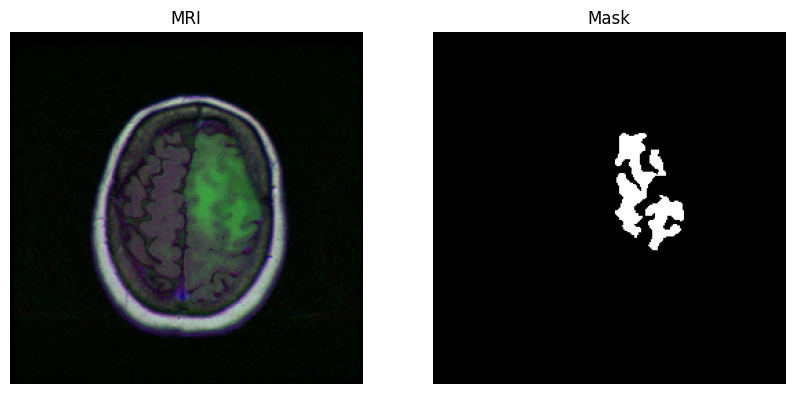

In [ ]:
image = cv2.imread(images[0])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(masks[0], 0)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("MRI")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()

### Splitting data

In [ ]:
train_images, val_test_images, train_masks, val_test_masks = train_test_split(
    images,
    masks,
    test_size=0.2,
    random_state=42
)
val_images, test_images, val_masks, test_masks = train_test_split(
    val_test_images,
    val_test_masks,
    test_size=0.5,
    random_state=42
)
print(f"Train Images: {len(train_images)}")
print(f"Train Masks : {len(train_masks)}")

print(f"Validation Images: {len(val_images)}")
print(f"Validation Masks : {len(val_masks)}")

print(f"Test Images: {len(test_images)}")
print(f"Test Masks : {len(test_masks)}")

Train Images: 3143
Train Masks : 3143
Validation Images: 393
Validation Masks : 393
Test Images: 393
Test Masks : 393


### Making Custom Dataset

In [ ]:
class BrainTumorDataset(Dataset):

    def __init__(self, image_paths, mask_paths, transform=None):

        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):

        return len(self.image_paths)

    def __getitem__(self, index):

        image_path = self.image_paths[index]
        mask_path = self.mask_paths[index]

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if self.transform:

            augmented = self.transform(image=image, mask=mask)

            image = augmented["image"]
            mask = augmented["mask"]

        mask = mask.unsqueeze(0).float()

        return image, mask

### Data Augumentation and Preprocessing

In [ ]:
train_transform = A.Compose([
    A.Resize(256, 256),

    A.HorizontalFlip(p=0.5),

    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.10,
        rotate_limit=20,
        p=0.5
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.3
    ),

    A.CLAHE(
        clip_limit=4.0,
        tile_grid_size=(8, 8),
        p=0.2
    ),

    A.GaussianBlur(
        blur_limit=(3, 5),
        p=0.1
    ),

    A.GaussNoise(
        std_range=(0.02, 0.05),
        p=0.2
    ),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    ),

    ToTensorV2()
])

In [ ]:
val_test_transform = A.Compose([
    A.Resize(256, 256),

    A.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225),
        ),

    ToTensorV2()
])

### Splitting Data

In [ ]:
train_dataset = BrainTumorDataset(
    train_images,
    train_masks,
    transform=train_transform
)

val_dataset = BrainTumorDataset(
    val_images,
    val_masks,
    transform=val_test_transform
)

test_dataset = BrainTumorDataset(
    test_images,
    test_masks,
    transform=val_test_transform
)

### Data loaders

In [ ]:
weights = []
for mask_path in train_masks:
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    weights.append(3.0 if mask.sum() > 0 else 1.0)

sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    sampler=sampler
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

### Model Configuration

In [ ]:
model = smp.UnetPlusPlus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

model = model.to(device)
print(model)

UnetPlusPlus(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential

In [ ]:
dice_loss = smp.losses.DiceLoss(
    mode="binary"
)
focal_loss = smp.losses.FocalLoss(mode="binary")

def criterion(pred, target):
    loss1 = dice_loss(pred, target)
    loss2 = focal_loss(pred, target)
    return 0.7 * loss1 + 0.3 * loss2

In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4)

In [ ]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=3,
    factor=0.1
)

### Trainig loop and Saving Models

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
save_dir = "/content/drive/MyDrive/brain_tumor_project"
os.makedirs(save_dir, exist_ok=True)

epochs = 50
patience = 7
best_loss = float("inf")
counter = 0
start_epoch = 0

checkpoint_path = os.path.join(save_dir, "checkpoint.pth")

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    if "scheduler_state_dict" in checkpoint:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    start_epoch = checkpoint["epoch"] + 1
    best_loss = checkpoint["best_loss"]

    print(f"Resuming from Epoch {start_epoch}")

for epoch in range(start_epoch, epochs):

    model.train()
    train_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]")

    for imgs, masks in loop:

        imgs = imgs.to(device)
        masks = masks.to(device)
        masks = (masks > 0).float()

        optimizer.zero_grad()

        preds = model(imgs)

        loss = criterion(preds, masks)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        loop.set_postfix(loss=loss.item())

    train_loss /= len(train_loader)

    scheduler.step(train_loss)

    print(f"Epoch [{epoch+1}/{epochs}] Average Loss: {train_loss:.4f}")

    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_loss": best_loss,
    }, checkpoint_path)

    if train_loss < best_loss:

        best_loss = train_loss
        counter = 0

        torch.save(model.state_dict(), os.path.join(save_dir, "best.pt"))

        print("Best model saved.")

    else:

        counter += 1

        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

torch.save(model.state_dict(), os.path.join(save_dir, "last_model.pt"))

Mounted at /content/drive


Epoch [1/50]: 100%|██████████| 197/197 [03:39<00:00,  1.12s/it, loss=0.171]


Epoch [1/50] Average Loss: 0.1850
Best model saved.


Epoch [2/50]: 100%|██████████| 197/197 [03:37<00:00,  1.11s/it, loss=0.146]


Epoch [2/50] Average Loss: 0.1253
Best model saved.


...

Epoch [48/50] Average Loss: 0.0576


Epoch [49/50]: 100%|██████████| 197/197 [03:37<00:00,  1.10s/it, loss=0.0443]


Epoch [49/50] Average Loss: 0.0566
Best model saved.


Epoch [50/50]: 100%|██████████| 197/197 [03:38<00:00,  1.11s/it, loss=0.0423]


Epoch [50/50] Average Loss: 0.0569


In [ ]:
torch.save(model.state_dict(), os.path.join(save_dir, "model.pt"))

In [ ]:
model.eval()

tp_total, fp_total, fn_total, tn_total = 0, 0, 0, 0

with torch.no_grad():
    for imgs, masks in tqdm(test_loader, desc="Evaluating"):
        imgs, masks = imgs.to(device), masks.to(device)
        masks = (masks > 0).long()

        preds = torch.sigmoid(model(imgs))
        preds = (preds > 0.5).long()

        tp, fp, fn, tn = smp.metrics.get_stats(preds, masks, mode="binary")
        tp_total += tp.sum()
        fp_total += fp.sum()
        fn_total += fn.sum()
        tn_total += tn.sum()

iou = smp.metrics.iou_score(tp_total, fp_total, fn_total, tn_total, reduction="micro")
f1 = smp.metrics.f1_score(tp_total, fp_total, fn_total, tn_total, reduction="micro")

print(f"IoU: {iou:.4f}")
print(f"Dice (F1): {f1:.4f}")

Evaluating: 100%|██████████| 25/25 [00:11<00:00,  2.11it/s]

IoU: 0.8379
Dice (F1): 0.9118


### Visualize Predictions on Test Batch

Images Shape : torch.Size([16, 3, 256, 256])
Masks Shape  : torch.Size([16, 1, 256, 256])
Preds Shape  : torch.Size([16, 1, 256, 256])
Prediction Min : 3.0145652640811704e-09
Prediction Max : 0.9999854564666748


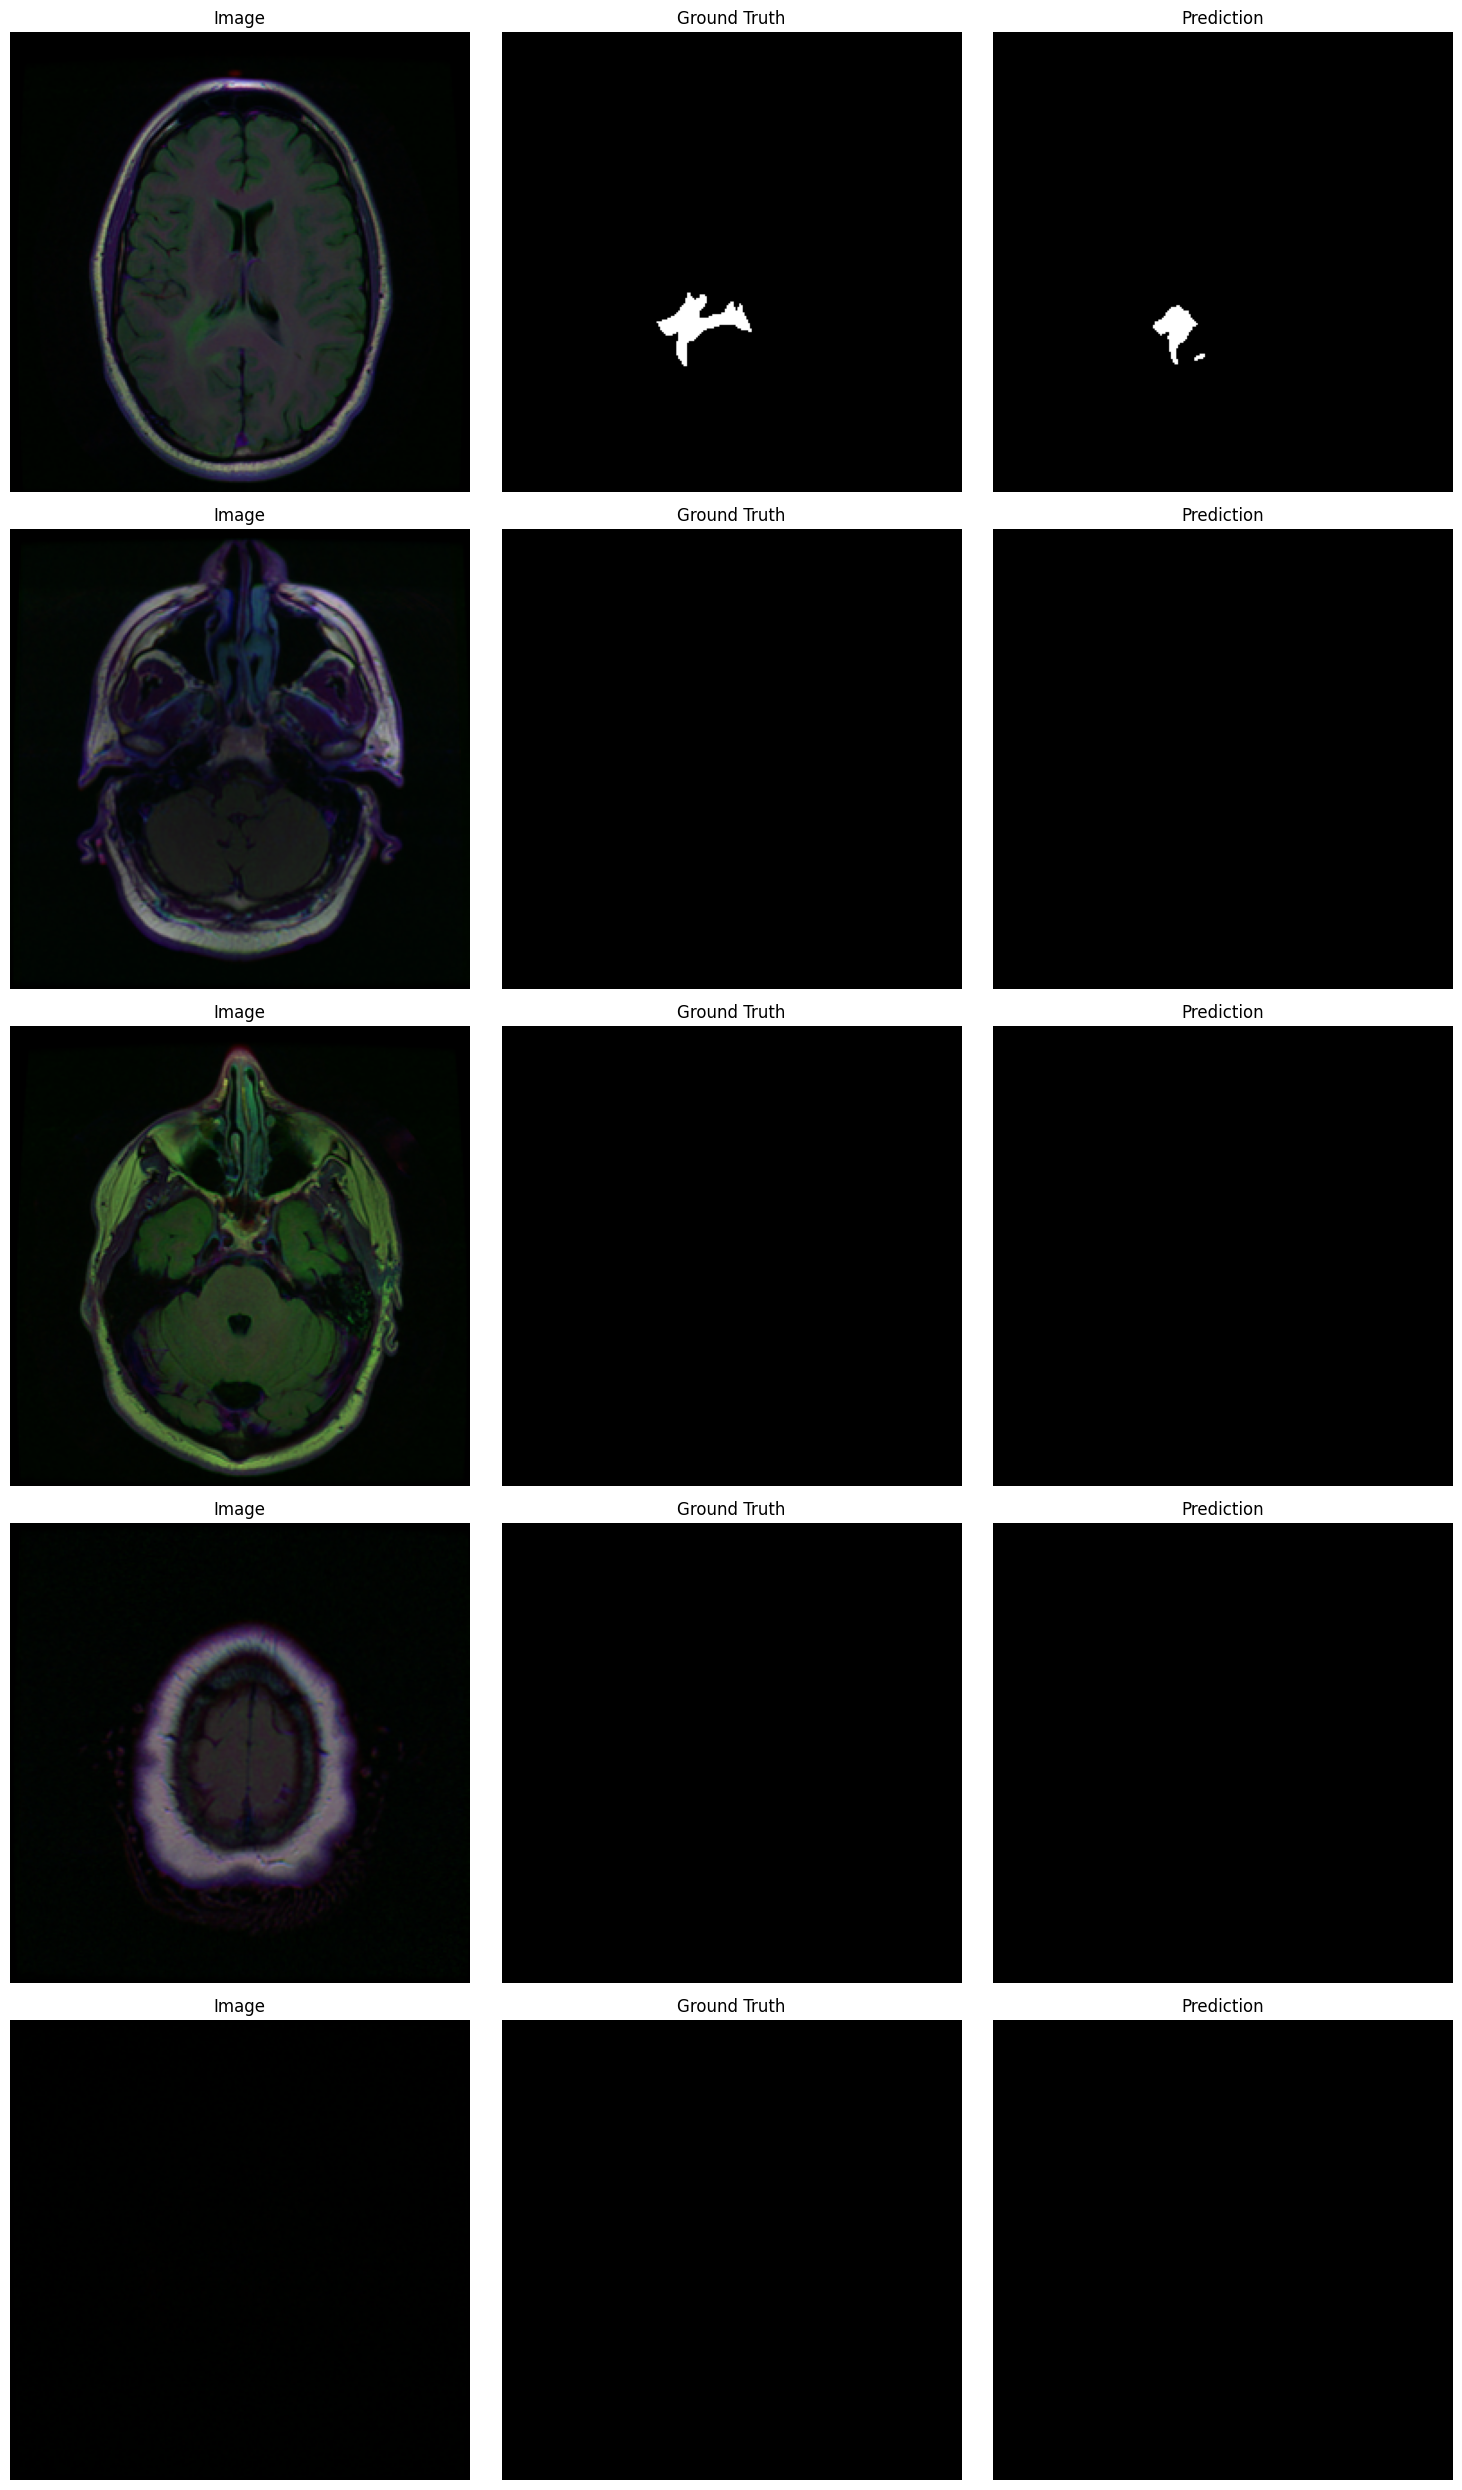

In [ ]:
model.eval()

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

with torch.no_grad():

    images, masks = next(iter(test_loader))

    images = images.to(device)
    masks = masks.to(device)

    outputs = model(images)

    probs = torch.sigmoid(outputs)
    preds = (probs > 0.5).float()

    images = images.cpu()
    masks = masks.cpu()
    preds = preds.cpu()

    print("Images Shape :", images.shape)
    print("Masks Shape  :", masks.shape)
    print("Preds Shape  :", preds.shape)

    print("Prediction Min :", probs.min().item())
    print("Prediction Max :", probs.max().item())

    n = min(5, images.size(0))

    plt.figure(figsize=(15, 5 * n))

    for i in range(n):

        if images.shape[1] == 3:

            img = images[i]

            img = img * std + mean
            img = img.permute(1, 2, 0).numpy()
            img = img.clip(0, 1)

            plt.subplot(n, 3, i * 3 + 1)
            plt.imshow(img)

        else:

            img = images[i].squeeze().numpy()

            plt.subplot(n, 3, i * 3 + 1)
            plt.imshow(img, cmap="gray")

        plt.title("Image")
        plt.axis("off")

        plt.subplot(n, 3, i * 3 + 2)
        plt.imshow(masks[i].squeeze(), cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(n, 3, i * 3 + 3)
        plt.imshow(preds[i].squeeze(), cmap="gray")
        plt.title("Prediction")
        plt.axis("off")

    plt.tight_layout()
    plt.show()